# 交接的活干到哪了

对着 [`HANDOFF.md`](HANDOFF.md) 一条一条说：哪些做完了，哪些没做完，没做完的卡在哪。
机器是 Isambard-AI（GH200，aarch64，驱动 565 / CUDA 12.7，分区 `workq`）。

没做完的每一项都有一个 notebook，里面有图、有数，还有一句「怎么算过了」——
那句话是在测之前写的，不是看完结果再补的。


## 图 1 — 一眼看完

HANDOFF 一共要求 12 件事。

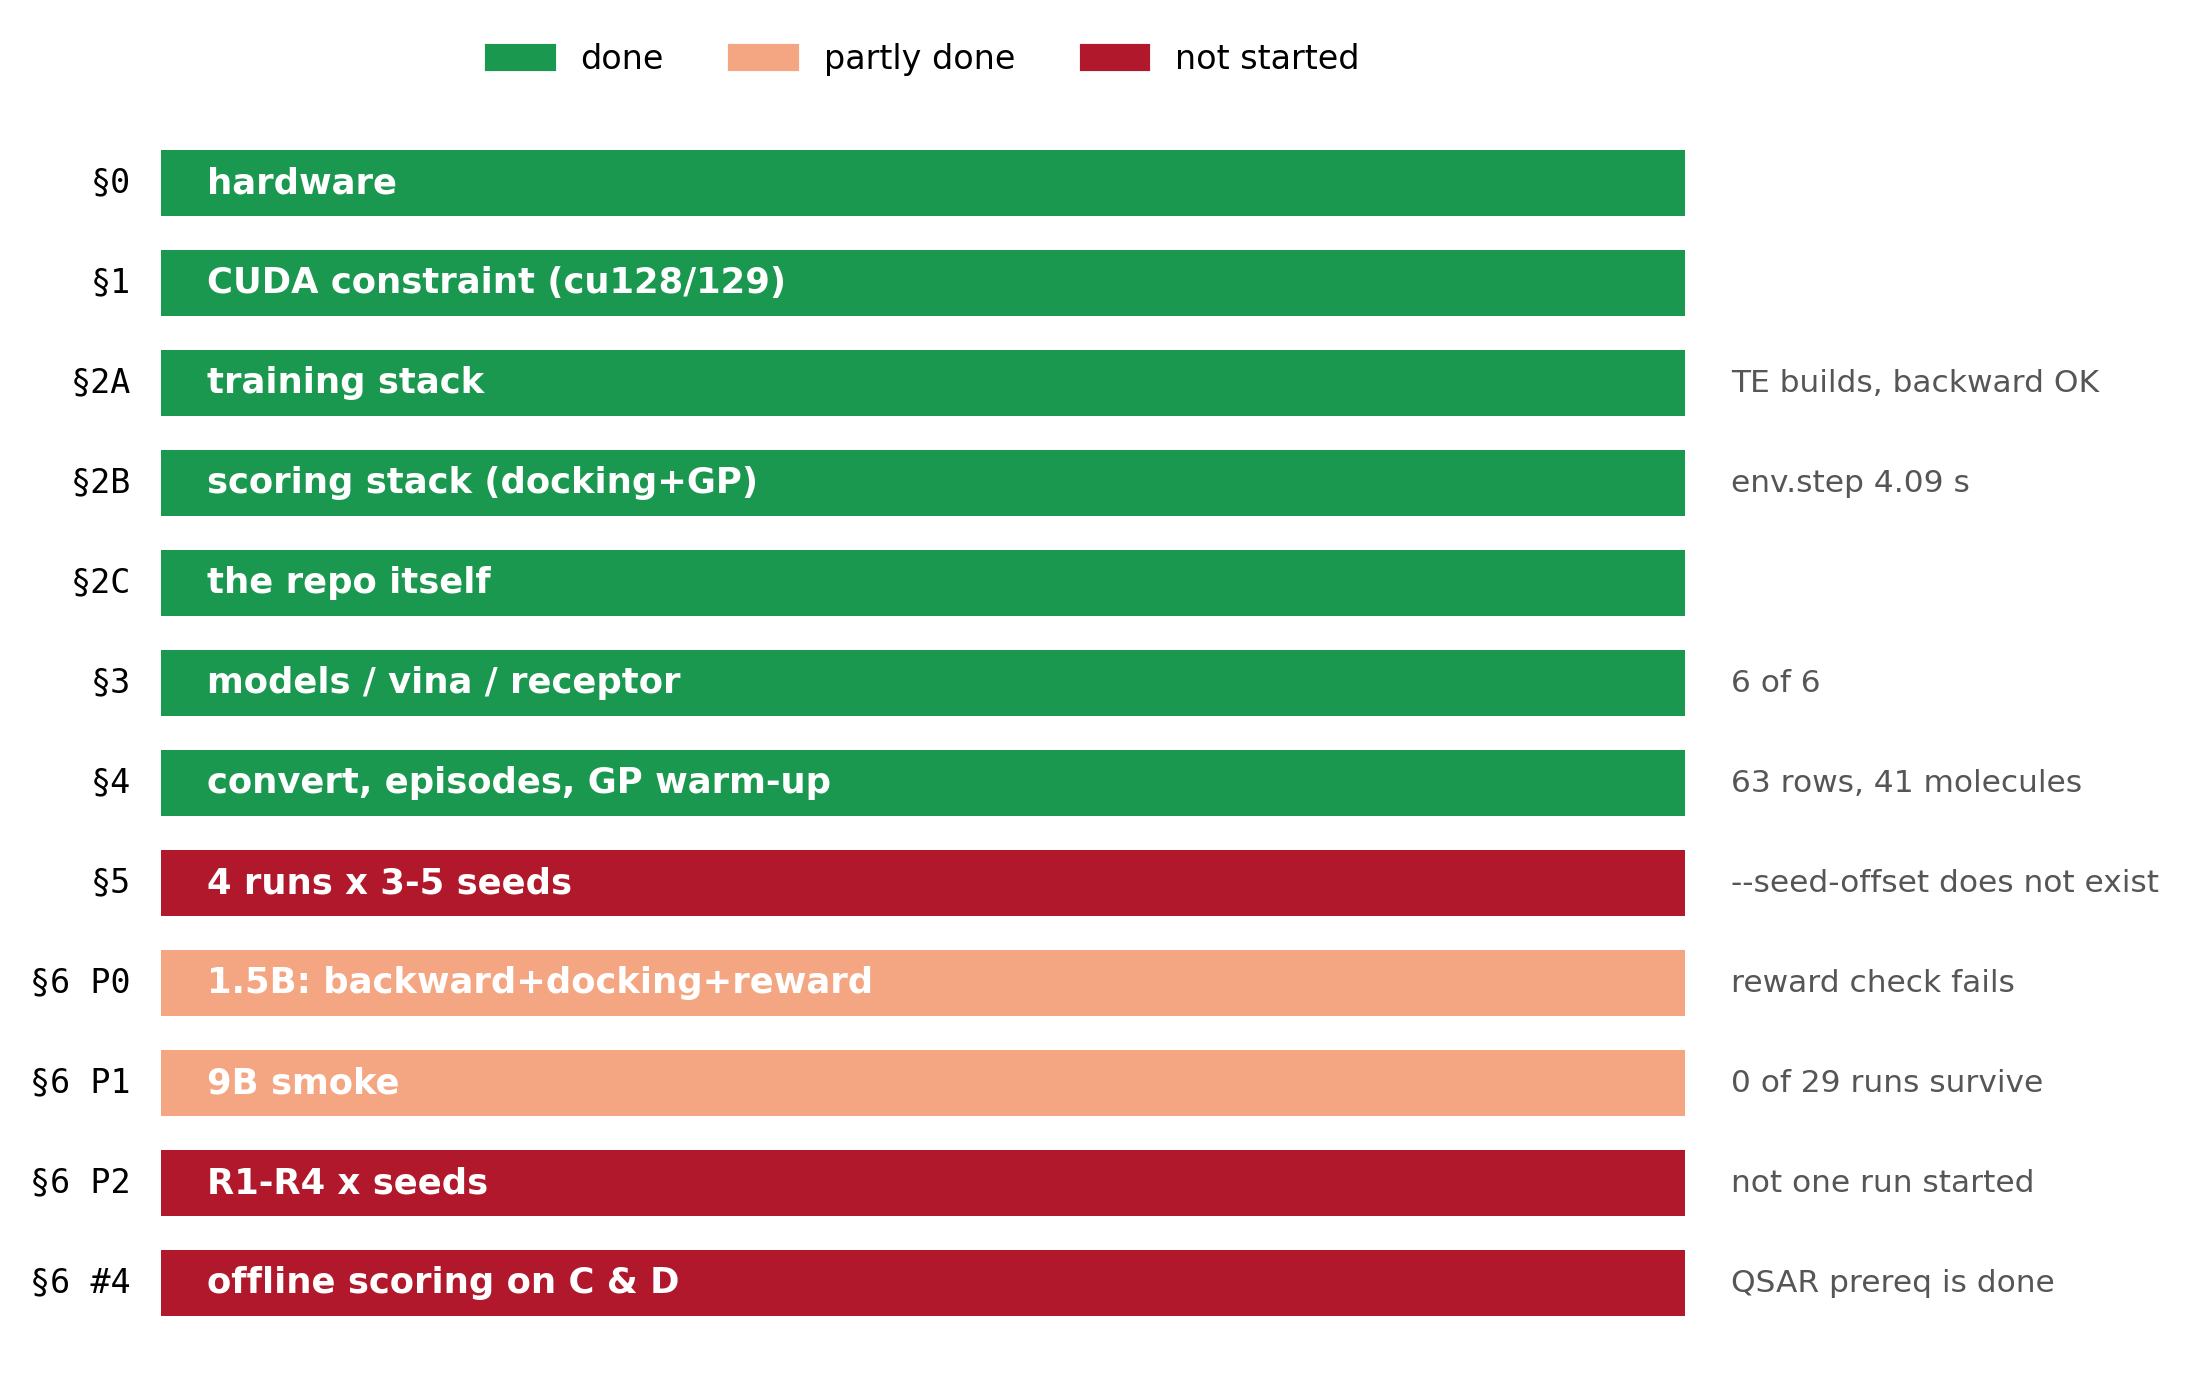

In [1]:
%matplotlib inline
import json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 300, "savefig.dpi": 300, "font.size": 9,
    "axes.grid": True, "grid.alpha": .25,
    "axes.spines.top": False, "axes.spines.right": False,
})
# 300 dpi 是硬要求，但 7 张 300 dpi 的图加起来 1.28 MB，越过 GitHub 内联渲染
# .ipynb 的上限（约 1 MB）——越过之后页面上只剩一句 Invalid Notebook，图一张都不显示。
#
# 缩 figsize 不是办法：字号是磅值、不随图缩小，缩完必然重叠（实测糊掉过一张）。
# 该动的是**每像素几个字节**：截成 256 色调色板 PNG，字节掉到约三分之一，
# 而这些都是线条图，本来就用不到 256 种颜色，肉眼没有差别。
#
# 这段必须待在 notebook 里，不能只写在构建脚本里：下一次
# `nbconvert --execute --inplace` 会把所有 cell 重跑一遍，
# 在外面做的压缩会被那次重跑原样撤销掉。
import io
from PIL import Image
from IPython.display import display as _display, Image as _IPyImage

def _show_compressed(*a, **k):
    for num in plt.get_fignums():
        f = plt.figure(num)
        buf = io.BytesIO()
        f.savefig(buf, format="png", bbox_inches="tight")
        buf.seek(0)
        im = Image.open(buf).convert("RGB").quantize(colors=256, method=Image.MAXCOVERAGE)
        out = io.BytesIO()
        im.save(out, format="PNG", optimize=True)
        _display(_IPyImage(data=out.getvalue()))
        plt.close(f)
plt.show = _show_compressed

R = Path("/lus/lfs1aip2/projects/public/u6gb/tasks/large-discovery-model/ldm_rl/results")
def load(n): return json.loads((R / n).read_text())

items = [
  # (section, label, state, note)
  ("§0",  "hardware",                       "done", ""),
  ("§1",  "CUDA constraint (cu128/129)",    "done", ""),
  ("§2A", "training stack",                 "done", "TE builds, backward OK"),
  ("§2B", "scoring stack (docking+GP)",     "done", "env.step 4.09 s"),
  ("§2C", "the repo itself",                "done", ""),
  ("§3",  "models / vina / receptor",       "done", "6 of 6"),
  ("§4",  "convert, episodes, GP warm-up",  "done", "63 rows, 41 molecules"),
  ("§5",  "4 runs x 3-5 seeds",             "todo", "--seed-offset does not exist"),
  ("§6 P0","1.5B: backward+docking+reward",  "part", "reward check fails"),
  ("§6 P1","9B smoke",                       "part", "0 of 29 runs survive"),
  ("§6 P2","R1-R4 x seeds",                  "todo", "not one run started"),
  ("§6 #4","offline scoring on C & D",       "todo", "QSAR prereq is done"),
]
col = {"done": "#1a9850", "part": "#f4a582", "todo": "#b2182b"}
fig, ax = plt.subplots(figsize=(7.4, 4.6))
y = np.arange(len(items))[::-1]
for (sec, lab, st, note), yy in zip(items, y):
    ax.barh(yy, 1, color=col[st], height=.66)
    ax.text(-0.02, yy, sec, ha="right", va="center", fontsize=8, family="monospace")
    ax.text(0.03, yy, lab, va="center", fontsize=8.5, color="white", weight="bold")
    if note:
        ax.text(1.03, yy, note, va="center", fontsize=7.5, color="#555555")
ax.set_xlim(0, 1); ax.set_ylim(-.6, len(items) - .4)
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values(): s.set_visible(False)
ax.grid(False)
ax.legend(handles=[Patch(color=col["done"], label="done"),
                   Patch(color=col["part"], label="partly done"),
                   Patch(color=col["todo"], label="not started")],
          frameon=False, fontsize=8, ncol=3, loc="upper center",
          bbox_to_anchor=(.5, 1.09))
plt.tight_layout(); plt.show()

**读法**：装机器、备数据这七项全做完了（绿）。橙的两项做了一半，
红的三项没开始。

**唯一挡在前面的是 §6 P0 那个 reward 检查**——它不过，P2 就算跑起来也学不到东西。

## 图 2 — 挡在前面的是什么：GRPO 拿不到梯度

先说我自己看错的一个地方。我一直盯着 `rollout/rewards`，看它总在 1e-8 上下，
就断定 reward 是零。**那个字段不是环境给的 reward**，是 GRPO 归一化之后的
advantage，`(r − mean) / std`。环境 reward 在同一个字典里，叫 `raw_reward`。

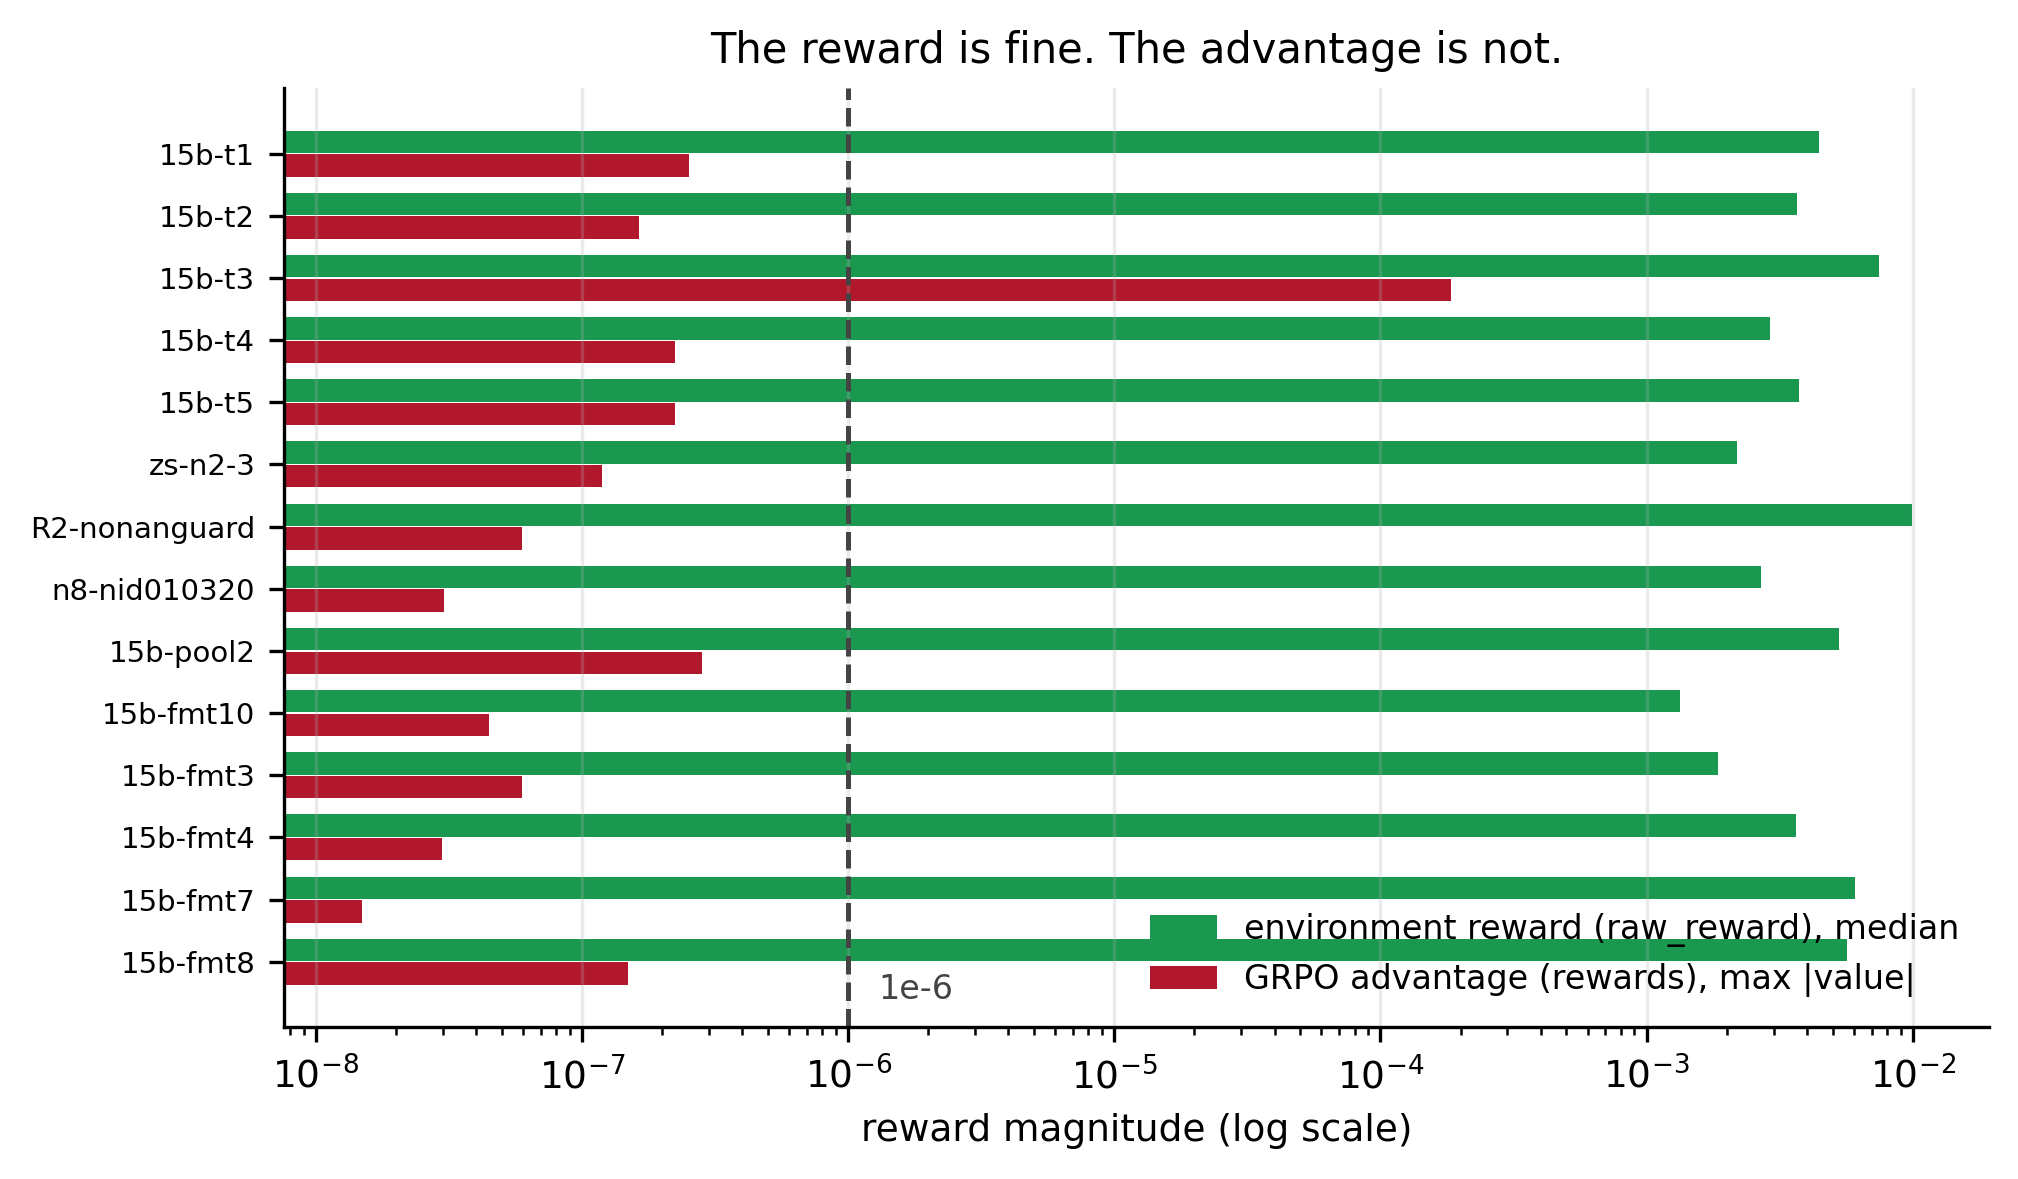

79 runs, 1097 steps · env reward > 1e-6: 972/1097 (89%) · zero-variance groups: 674


In [2]:
aud = load("reward_audit.json")
runs = sorted([r for r in aud["runs"] if r["n_steps"] >= 15],
              key=lambda r: -r["n_steps"])[:14]
fig, ax = plt.subplots(figsize=(6.8, 4.0))
y = np.arange(len(runs))
ax.barh(y - .19, [max(r["raw_median"], 1e-9) for r in runs], height=.36,
        color="#1a9850", label="environment reward (raw_reward), median")
ax.barh(y + .19, [max(r["adv_max_abs"], 1e-9) for r in runs], height=.36,
        color="#b2182b", label="GRPO advantage (rewards), max |value|")
ax.set_yticks(y); ax.set_yticklabels([r["run"][:22] for r in runs], fontsize=7)
ax.invert_yaxis(); ax.set_xscale("log")
ax.axvline(1e-6, ls="--", lw=1.2, color="#444444")
ax.text(1.3e-6, len(runs)-.4, "1e-6", fontsize=8, color="#444444")
ax.set_xlabel("reward magnitude (log scale)")
ax.set_title("The reward is fine. The advantage is not.", fontsize=10)
ax.legend(frameon=False, fontsize=8, loc="lower right"); ax.grid(axis="y", alpha=0)
plt.tight_layout(); plt.show()
n = aud["n_steps_total"]
print(f'{aud["n_runs"]} runs, {n} steps · '
      f'env reward > 1e-6: {aud["raw_above_1e6_total"]}/{n} '
      f'({100*aud["raw_above_1e6_total"]/n:.0f}%) · '
      f'zero-variance groups: {aud["zero_std_total"]}')

**读法**：绿的（环境 reward）几乎全在 1e-6 右边，多数在 1e-2 附近，
正是 EHVI 该有的大小——**reward 一点毛病没有**。红的（归一化之后的 advantage）
全贴在左边。

差在哪：GRPO 要拿一组里几条轨迹的标准差去除。**几条轨迹的 reward 一模一样时，
分子分母同时是 0**，这一组对参数更新一点贡献都没有，reward 再大也白搭。

## 图 3 — 本来以为是解析失败，测下来不是

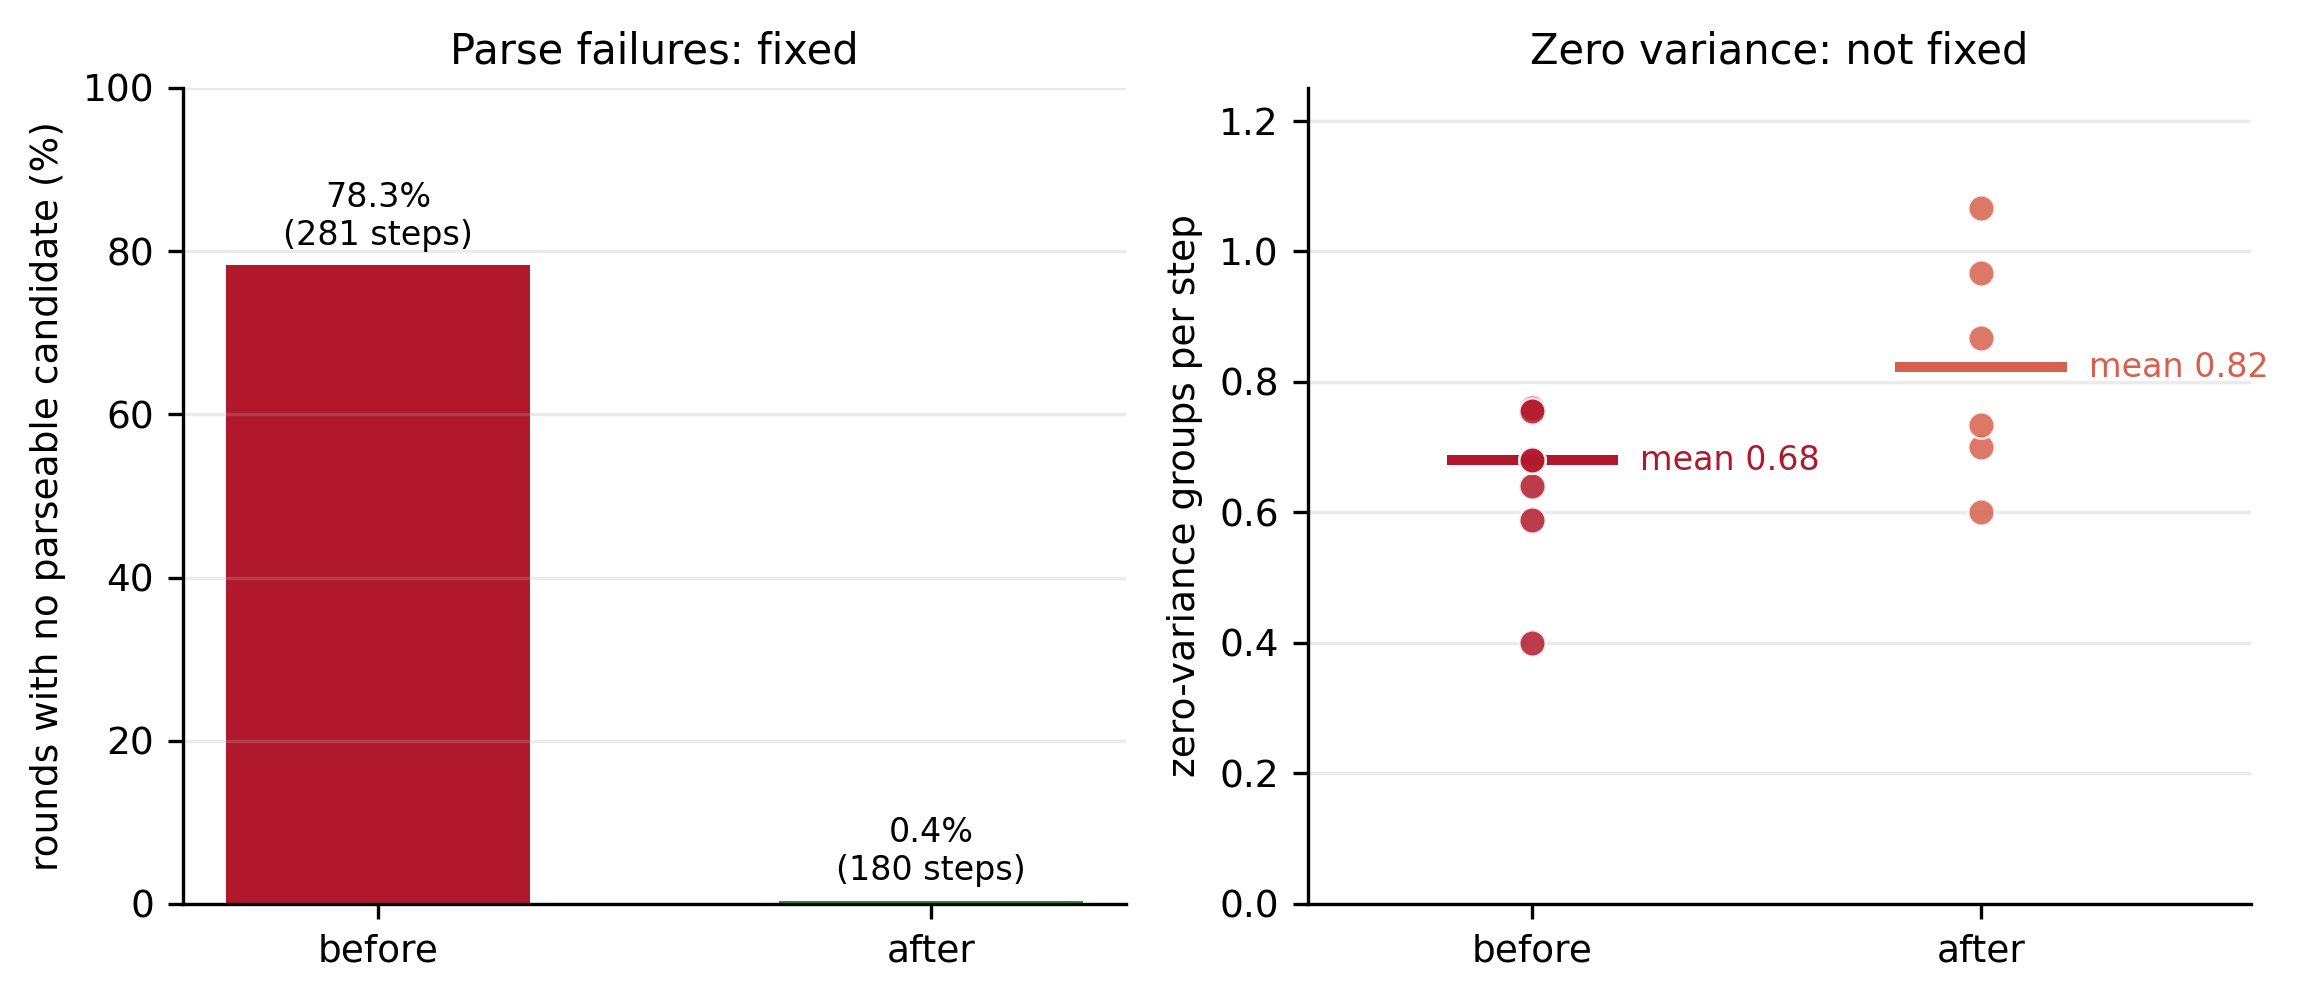

In [3]:
fix = load("chat_format_fix.json")
b, a = fix["before"], fix["after"]
fig, axes = plt.subplots(1, 2, figsize=(7.8, 3.4))

ax = axes[0]
bars = ax.bar(["before", "after"], [100*b["fail_rate"], 100*a["fail_rate"]],
              color=["#b2182b", "#1a9850"], width=.55)
for r_, v, n_ in zip(bars, [100*b["fail_rate"], 100*a["fail_rate"]], [b["steps"], a["steps"]]):
    ax.text(r_.get_x()+r_.get_width()/2, v+2.5, f"{v:.1f}%\n({n_} steps)",
            ha="center", fontsize=8)
ax.set_ylim(0, 100); ax.set_ylabel("rounds with no parseable candidate (%)")
ax.set_title("Parse failures: fixed", fontsize=10); ax.grid(axis="x", alpha=0)

# 逐 run 的点，不只是池化均值 —— 池化数字在小样本上指错过一次方向
ax = axes[1]
for i, (k, c) in enumerate([("before", "#b2182b"), ("after", "#d6604d")]):
    pts = fix[k]["per_run_zps"]
    ax.scatter([i]*len(pts), pts, s=40, color=c, alpha=.85, zorder=3,
               edgecolors="white", linewidths=.6)
    ax.plot([i-.18, i+.18], [fix[k]["zero_std_per_step"]]*2, lw=2.4, color=c, zorder=2)
    ax.text(i+.24, fix[k]["zero_std_per_step"], f'mean {fix[k]["zero_std_per_step"]:.2f}',
            va="center", fontsize=8, color=c)
ax.set_xticks([0, 1]); ax.set_xticklabels(["before", "after"])
ax.set_xlim(-.5, 1.6); ax.set_ylim(0, 1.25)
ax.set_ylabel("zero-variance groups per step")
ax.set_title("Zero variance: not fixed", fontsize=10); ax.grid(axis="x", alpha=0)
plt.tight_layout(); plt.show()

**读法**：左边——环境给的观测本来是直接接在模型上一轮回答后面的，
把 chat 格式弄坏了，从第 1 轮起模型就不再输出 JSON。包成一个独立的 user turn
之后，**解析失败率 78.3% → 0.4%**，1249 次失败变成 2 次。

右边——**零方差没跟着降**（0.68 → 0.82）。按事先写好的那句标准，
这说明解析失败不是零方差的原因，下一步该查 `n_samples_per_prompt`。
**那个测量已经做完了，见下面图 4。**

（中间我报过一次「降了 43%」，那是新代码只跑了 36 步时的读数，跑到 180 步就翻过来了。
现在只算跑够 15 步的 run——只跑几步的 run 这个数噪声大到没意义，0.00 和 1.00 都出现过。
**画逐 run 的点而不只是池化均值，就是为了不再被这种事骗一次。**）

## 图 4 — 零方差的成因定了：组内只有两条轨迹

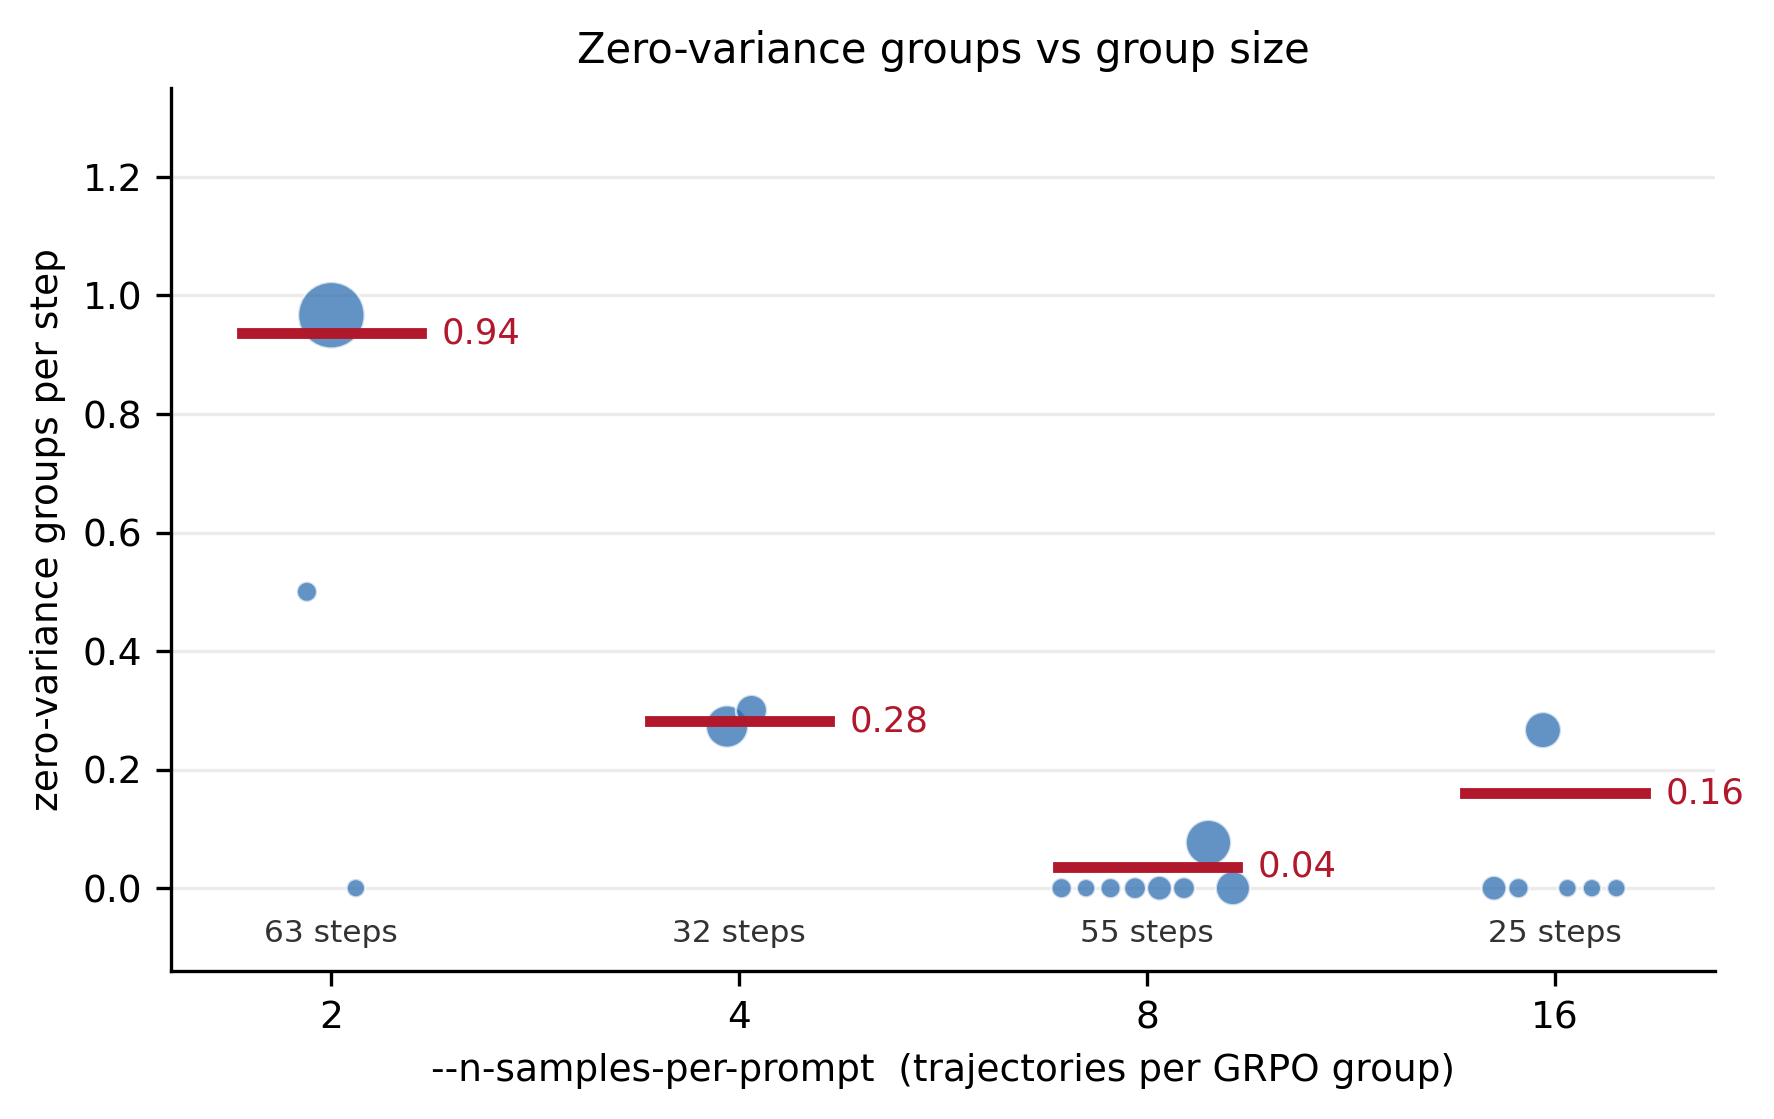

n=2   3 runs,  63 steps, zero_std/step=0.94
n=4   2 runs,  32 steps, zero_std/step=0.28
n=8   8 runs,  55 steps, zero_std/step=0.04
n=16  6 runs,  25 steps, zero_std/step=0.16


In [4]:
sw = load("zerovar_sweep.json")
arms = [sw["arms"][k] for k in ("2", "4", "8", "16")]
fig, ax = plt.subplots(figsize=(6.0, 3.8))
for i, a in enumerate(arms):
    xs = [i + (j - (len(a["per_run"]) - 1) / 2) * 0.06 for j in range(len(a["per_run"]))]
    ys = [r["zero_std_per_step"] for r in a["per_run"]]
    sz = [16 + 4 * r["steps"] for r in a["per_run"]]
    ax.scatter(xs, ys, s=sz, color="#2166ac", alpha=.7, zorder=3,
               edgecolors="white", linewidths=.6)
    ax.plot([i - .22, i + .22], [a["zero_std_per_step"]] * 2, lw=2.6,
            color="#b2182b", zorder=4)
    ax.text(i + .27, a["zero_std_per_step"], f'{a["zero_std_per_step"]:.2f}',
            va="center", fontsize=8.5, color="#b2182b")
    ax.text(i, -0.09, f'{a["steps"]} steps', ha="center", fontsize=7.5, color="#333333")
ax.set_xticks(range(4)); ax.set_xticklabels(["2", "4", "8", "16"])
ax.set_xlabel("--n-samples-per-prompt  (trajectories per GRPO group)")
ax.set_ylabel("zero-variance groups per step")
ax.set_ylim(-0.14, 1.35)
ax.set_title("Zero-variance groups vs group size", fontsize=10)
ax.grid(axis="x", alpha=0)
plt.tight_layout(); plt.show()
for a in arms:
    print(f'n={a["n_samples"]:<3} {a["n_runs_with_data"]} runs, {a["steps"]:>3} steps, '
          f'zero_std/step={a["zero_std_per_step"]:.2f}')

**读法**：点是单个 run（越大跑得越多），红线是该档所有 run 合起来的值。
四档除了 `n_samples_per_prompt` 之外一切相同，同期起跑，都跑够了 15 步。

**0.94 → 0.28 → 0.04 → 0.16**（数据截止 08:45Z，1.5B 的 run 已全部结束）。

相邻两档做 Fisher 精确检验：

| 比较 | 事件/步数 | p | |
|---|---|---:|---|
| n=2 vs n=4 | 59/63 → 9/32 | <0.0001 | 显著 |
| n=4 vs n=8 | 9/32 → 2/55 | **0.0016** | 显著 |
| n=8 vs n=16 | 2/55 → 4/25 | 0.073 | **分不出** |

n=16 的率是 n=8 的 4.4 倍，看着像「16 反而更差」，但只有 6 次事件，
**撑不起这个比较**。正确的说法是「n≥8 都很低，8 与 16 之间分辨不出」。

**事件数是个位数时，率之间的倍数关系基本没有信息量**——所以这张表
把计数和率并排放。

道理很直白：GRPO 的梯度来自组内差异。一组只有两条轨迹时，两条撞出同一个
分子就足以让标准差为 0；组越大，全部撞在一起的概率越低。

**对 P2 的意义**：`n_samples` 直接乘在每步的 rollout 成本上，所以能用小的
就别用大的。4 压掉 70%，8 之后基本消除，**16 没有额外收益、只是更贵**。

### 第二个成因也定了：GP 历史变长

上面那条「读数随测量期间缓慢上升」原本只是趋势。把**同一个 run 的前后半**
拿来比就能定它——n 在一个 run 内是固定的，所以差异只能来自训练进度：

| run | n | 步数 | 前半 | 后半 |
|---|---:|---:|---:|---:|
| zs-n2-3 | 2 | 60 | 0.80 | **1.13** |
| zs-n4-3 | 4 | 22 | 0.00 | **0.55** |
| zs-n4-4 | 4 | 10 | 0.20 | **0.40** |
| zs-n8-7 | 8 | 12 | 0.00 | 0.00 |

**三升零降一持平**，加权 0.48 → 0.81。这与 notebook 05 里那张 EHVI 衰减图吻合：
GP 历史越长，一组候选一起拿到 0 的概率越高。n=8 那条持平在 0，
是因为它没有可升的空间——八条轨迹即使 EHVI 变小也不会全撞在一起。

**所以两个成因是叠加的**：`n_samples` 定基线高度，GP 历史长度定它爬多快。
把 n 提到 8 同时压住了两者。

## 图 5 — 换 reward 和加轨迹，各自值多少

陈奕杭的提议一次改了两件事（reward 从 acquisition 换成 ΔHV，同时 n 从 2 提到 4）。
捆在一起，零方差降了也说不清是哪一件在起作用。所以把 n=2 那两格也跑了，
把它变成一个 2×2，两个因子就能各自读出来。

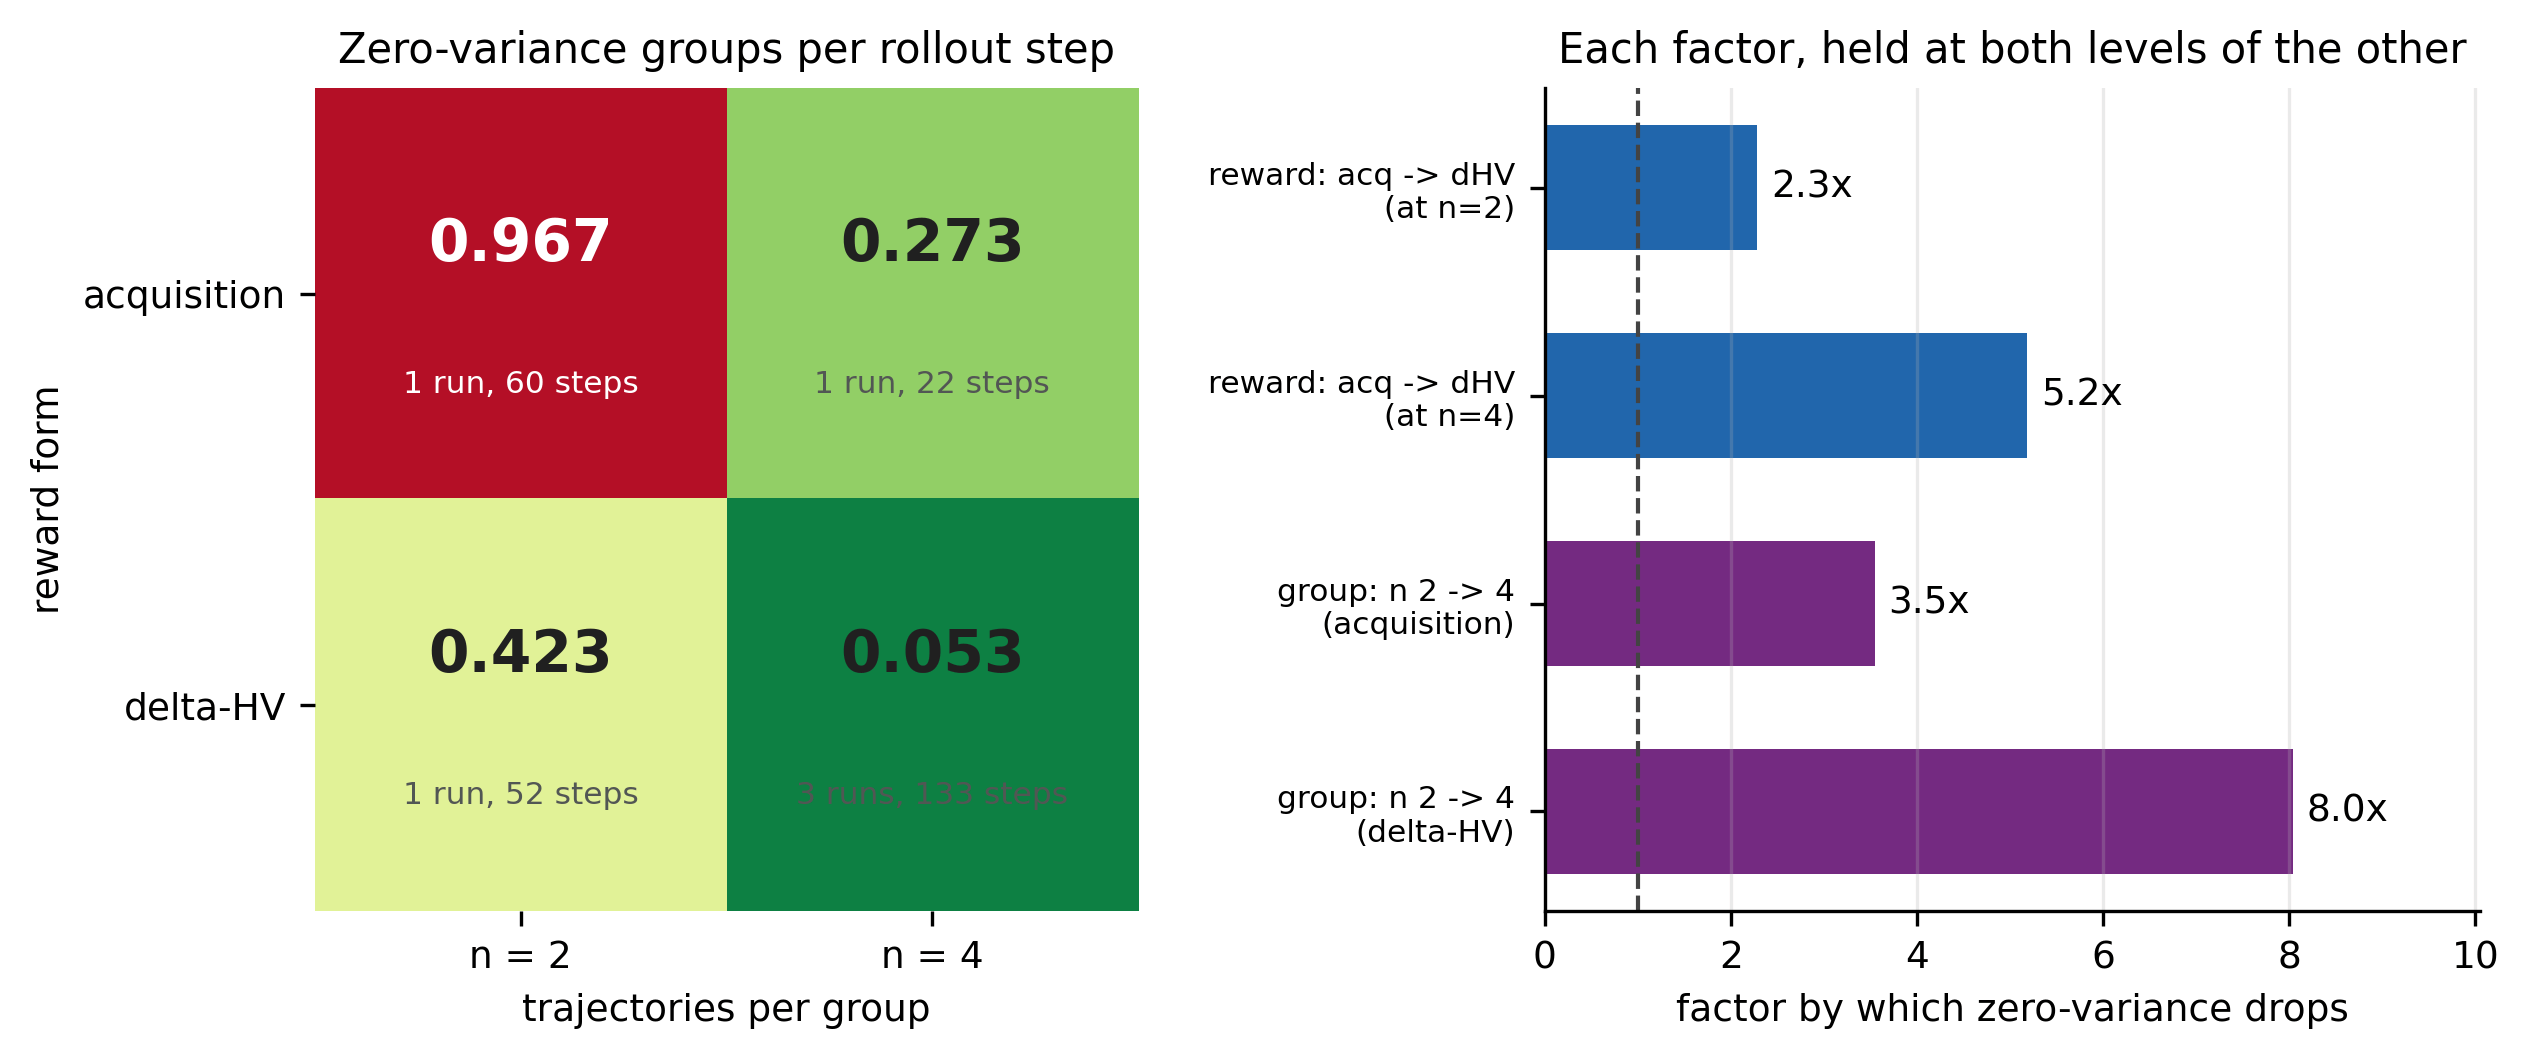

cells resting on a single run: ['acquisition_n2', 'acquisition_n4', 'hypervolume_n2']


In [5]:
rg = load("reward_x_group.json")["cells"]
grid = [[rg["acquisition_n2"], rg["acquisition_n4"]],
        [rg["hypervolume_n2"], rg["hypervolume_n4"]]]
fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.6),
                         gridspec_kw={"width_ratios": [1.05, 1]})

# left: the 2x2 itself
ax = axes[0]
vals = np.array([[c["zero_std_per_step"] for c in row] for row in grid])
im = ax.imshow(vals, cmap="RdYlGn_r", vmin=0, vmax=1.0)
for i in range(2):
    for j in range(2):
        c = grid[i][j]
        ax.text(j, i - .12, f'{c["zero_std_per_step"]:.3f}', ha="center", va="center",
                fontsize=14, weight="bold",
                color="white" if vals[i, j] > .55 else "#222222")
        ax.text(j, i + .22, f'{c["runs_used"]} run{"s" if c["runs_used"]>1 else ""}, '
                            f'{c["steps"]} steps', ha="center", va="center", fontsize=7.5,
                color="white" if vals[i, j] > .55 else "#555555")
ax.set_xticks([0, 1]); ax.set_xticklabels(["n = 2", "n = 4"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["acquisition", "delta-HV"])
ax.set_xlabel("trajectories per group"); ax.set_ylabel("reward form")
ax.set_title("Zero-variance groups per rollout step", fontsize=10)
ax.grid(False)
for sp in ax.spines.values(): sp.set_visible(False)

# right: each factor on its own, at both levels of the other
ax = axes[1]
eff = [("reward: acq -> dHV\n(at n=2)", vals[0,0]/vals[1,0]),
       ("reward: acq -> dHV\n(at n=4)", vals[0,1]/vals[1,1]),
       ("group: n 2 -> 4\n(acquisition)", vals[0,0]/vals[0,1]),
       ("group: n 2 -> 4\n(delta-HV)",    vals[1,0]/vals[1,1])]
y = np.arange(len(eff))
cols = ["#2166ac", "#2166ac", "#762a83", "#762a83"]
b = ax.barh(y, [e[1] for e in eff], color=cols, height=.6)
for r_, (lab, v) in zip(b, eff):
    ax.text(v + .15, r_.get_y() + r_.get_height()/2, f"{v:.1f}x", va="center", fontsize=9)
ax.set_yticks(y); ax.set_yticklabels([e[0] for e in eff], fontsize=7.5)
ax.invert_yaxis(); ax.axvline(1, ls="--", lw=1, color="#444444")
ax.set_xlabel("factor by which zero-variance drops")
ax.set_title("Each factor, held at both levels of the other", fontsize=10)
ax.set_xlim(0, max(e[1] for e in eff) * 1.25); ax.grid(axis="y", alpha=0)
plt.tight_layout(); plt.show()
print("cells resting on a single run:",
      [k for k, c in rg.items() if c["single_run_only"]])

**读法**：左边四格，往右往下都在降。右边把两个因子拆开：
**换 reward 在 n=2 时除以 2.3、在 n=4 时除以 5.2；加轨迹在 acquisition 下除以 3.5、
在 ΔHV 下除以 8.0。** 四根柱子都在 1 的右边，所以**两个因子各自都有效，不是其中一个
在带另一个**——这正是捆在一起测不出来的东西。

**但四格里有三格只有一个 run**（代码里 `single_run_only` 会把它们打出来）。
一个 run 给不出格内散布，也就没法说这些差值比噪声大多少。补的四个 ΔHV n=2
正在跑，数到了再更新，不拿 n=1 硬撑。

## 图 6 — 9B 为什么起不来：TP=4 被拆到了两个节点上

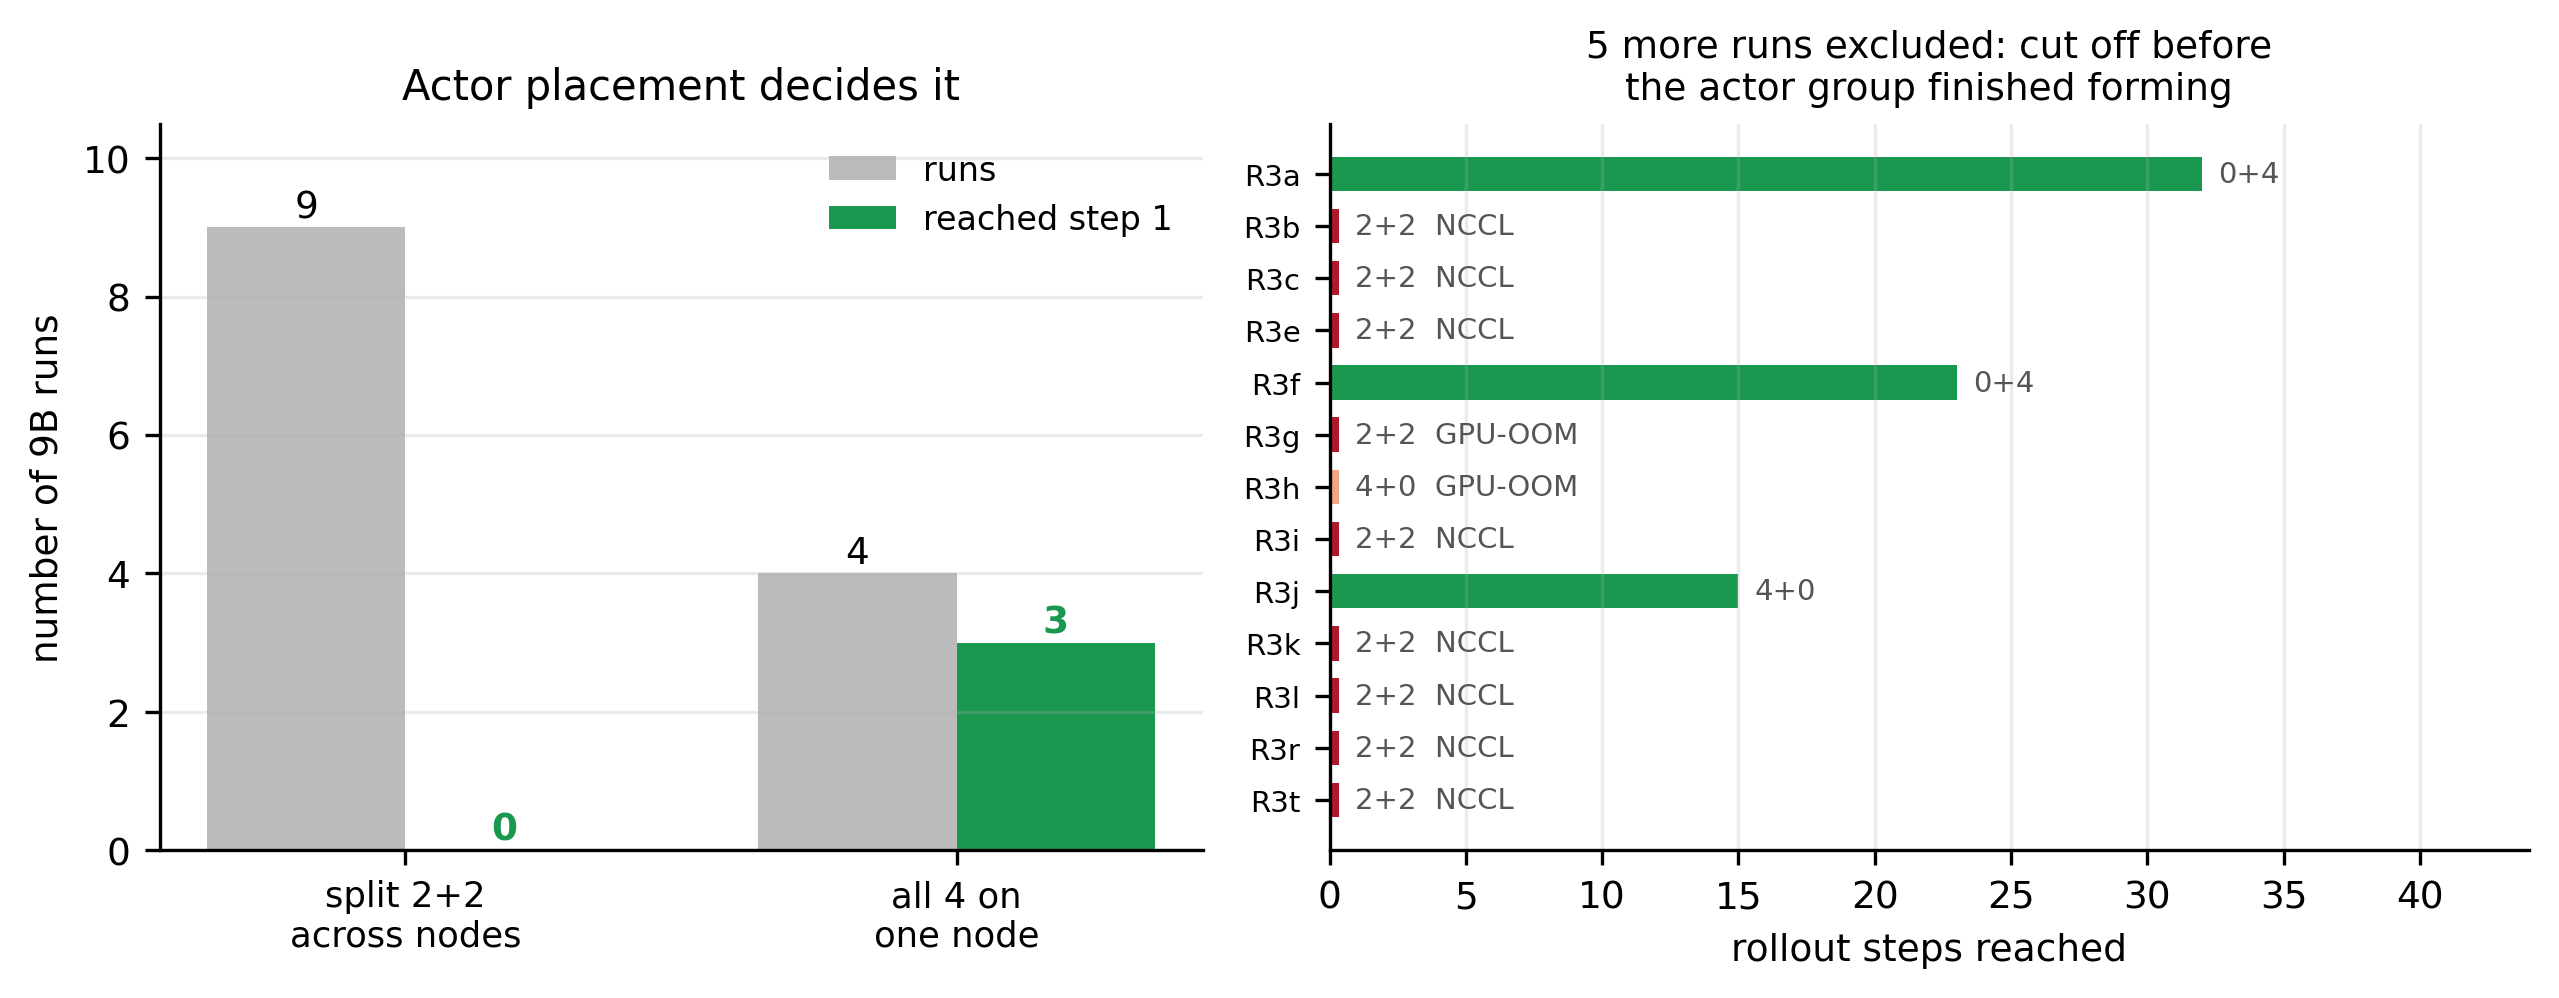

In [6]:
pl = load("nine_b_placement.json")
S, runs = pl["summary"], pl["runs"]
fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.4),
                         gridspec_kw={"width_ratios": [1, 1.15]})

ax = axes[0]
cats = [("split 2+2\nacross nodes", S["split"]), ("all 4 on\none node", S["one_node"])]
x = np.arange(len(cats))
ax.bar(x - .18, [c["runs"] for _, c in cats], width=.36, color="#bbbbbb", label="runs")
ax.bar(x + .18, [c["trained"] for _, c in cats], width=.36, color="#1a9850",
       label="reached step 1")
for i, (_, c) in enumerate(cats):
    ax.text(i - .18, c["runs"] + .15, str(c["runs"]), ha="center", fontsize=9)
    ax.text(i + .18, c["trained"] + .15, str(c["trained"]), ha="center", fontsize=9,
            color="#1a9850", weight="bold")
ax.set_xticks(x); ax.set_xticklabels([n for n, _ in cats], fontsize=8.5)
ax.set_ylabel("number of 9B runs"); ax.set_ylim(0, 10.5)
ax.set_title("Actor placement decides it", fontsize=10)
ax.legend(frameon=False, fontsize=8); ax.grid(axis="x", alpha=0)

ax = axes[1]
shown = [r for r in runs if r["placement"] != "censored"]
y = np.arange(len(shown))
for i, r in enumerate(shown):
    c = "#1a9850" if r["trained"] else ("#b2182b" if r["placement"] == "split" else "#f4a582")
    ax.barh(i, max(r["steps"], .35), color=c, height=.66)
    tag = f'{r["on_head"]}+{r["on_remote"]}'
    if r["nccl_error"]: tag += "  NCCL"
    elif r["gpu_oom"]:  tag += "  GPU-OOM"
    ax.text(max(r["steps"], .35) + .6, i, tag, va="center", fontsize=7, color="#555555")
ax.set_yticks(y); ax.set_yticklabels([r["run"] for r in shown], fontsize=7)
ax.invert_yaxis(); ax.set_xlabel("rollout steps reached")
ax.set_xlim(0, 44)
ax.set_title(f'{S["censored"]["runs"]} more runs excluded: cut off before\n'
             f'the actor group finished forming', fontsize=9)
ax.grid(axis="y", alpha=0)
plt.tight_layout(); plt.show()

**读法**：**actor 的四个 rank 被拆到两个节点上的，9 个里 0 个跑起来**，
其中 8 个日志里有 `NCCL Error 2`——TP=4 的 all-gather 要跨 Slingshot，
在加载检查点的 gather 那一步倒掉。整组落在一个节点上的 4 个里跑起来 3 个
（32 / 23 / 15 步）。

例外那个（R3h）是另一回事：它那张卡上有两个邻居各占 29 GiB，是显存撞死的，不是 NCCL。

**右图故意排除了 5 个 run**：它们的日志在 actor 组凑齐 4 个之前就断了，
「0 步」的意思是「还没来得及试」，不是「试了没成」。把它们算成失败，
one-node 那一列就会凭空多出 5 个零。

**为什么会拆**：slime 只开一个 placement group，把 actor 和 rollout 的 bundle 装在一起，
按 `(节点 IP, GPU 号)` 排序后取前 4 个给 actor。**没有任何东西把 actor 钉在一个节点上**——
落不落得整齐，取决于哪个节点的高速网地址数值更小。修法是起跑前解析两侧的 `10.100.*`
地址，把小的那个指派成 actor 节点。注意必须取高速网那个地址：`getent hosts nid010873`
给的是 `10.242.12.139`，而 Ray 报的是 `10.100.29.20`，两个网段之间不保序。

## 图 7 — 另一件没做完的：9B 的 run 活不下来

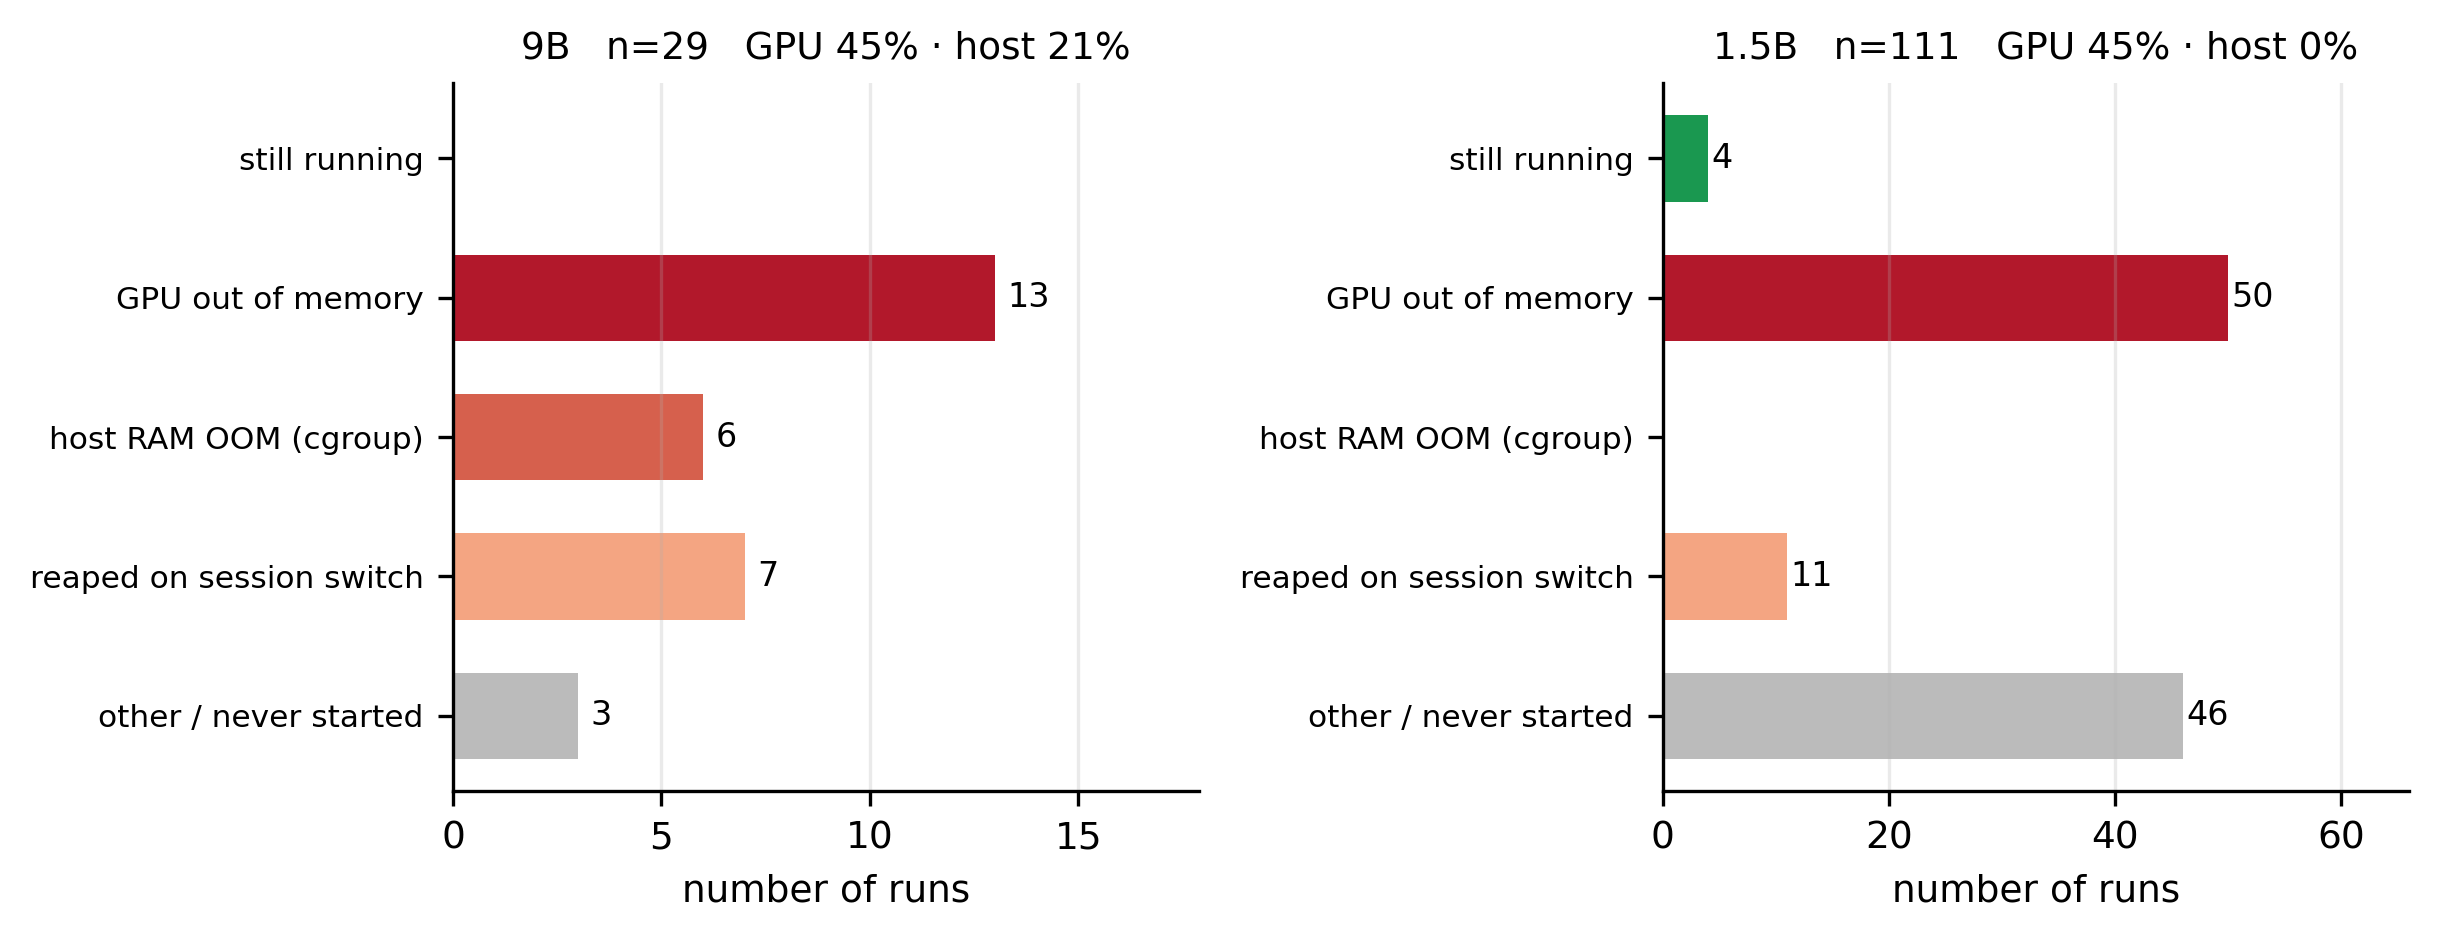

In [7]:
from collections import Counter
ro = load("run_outcomes.json")
c9 = Counter(r["outcome"] for r in ro if r["size"] == "9B")
c15 = Counter(r["outcome"] for r in ro if r["size"] == "1.5B")
n9, n15 = sum(c9.values()), sum(c15.values())
order = ["alive", "gpu_oom", "host_oom", "session_kill", "other"]
lab = {"alive": "still running", "gpu_oom": "GPU out of memory",
       "host_oom": "host RAM OOM (cgroup)", "session_kill": "reaped on session switch",
       "other": "other / never started"}
col2 = {"alive": "#1a9850", "gpu_oom": "#b2182b", "host_oom": "#d6604d",
        "session_kill": "#f4a582", "other": "#bbbbbb"}
fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.2))
for ax, (size, cnt, n_) in zip(axes, [("9B", c9, n9), ("1.5B", c15, n15)]):
    vals = [cnt.get(k, 0) for k in order]
    bars = ax.barh(range(len(order)), vals, color=[col2[k] for k in order], height=.62)
    ax.set_yticks(range(len(order))); ax.set_yticklabels([lab[k] for k in order], fontsize=7.5)
    ax.invert_yaxis(); ax.set_xlabel("number of runs")
    ax.set_title(f"{size}   n={n_}   GPU {100*cnt.get('gpu_oom',0)/n_:.0f}% · "
                 f"host {100*cnt.get('host_oom',0)/n_:.0f}%", fontsize=9)
    for r_, v in zip(bars, vals):
        if v: ax.text(v+.3, r_.get_y()+r_.get_height()/2, str(v), va="center", fontsize=8)
    ax.set_xlim(0, max(vals)*1.3+1); ax.grid(axis="y", alpha=0)
plt.tight_layout(); plt.show()

**读法**：**主机内存被 OOM killer 杀掉这一类只出现在 9B，1.5B 一个都没有**——
9B 加载检查点时占的主机内存大得多。

这两类得反着修：显存被邻居占满基本没办法（`nodelock` 被禁之后没法预留），
主机内存那种起跑前查得出来——上限在 job 这一级的 cgroup 上，
同一个分配里所有 step 一起分 449 GB。

## 逐条对照

In [8]:
tbl = pd.DataFrame([
 ["§0",  "hardware",                      "done",  "-"],
 ["§1",  "torch cu128/cu129 only",        "done",  "cu130 confirmed broken"],
 ["§2A", "training stack",                "done",  "TE installs, backward OK"],
 ["§2B", "scoring stack",                 "done",  "aarch64 vina, env.step 4.09 s"],
 ["§2C", "the repo",                      "done",  "-"],
 ["§3",  "assets",                        "done",  "6 of 6"],
 ["§4",  "one-time preparation",          "done",  "63 rows, 41 molecules"],
 ["§5",  "4 runs x 3-5 seeds",            "TODO",  "see 03, 06"],
 ["§6 P0","backward + docking + reward",   "PART",  "reward fails, see 01"],
 ["§6 P1","9B smoke",                     "PART",  "0/29 alive, see 02"],
 ["§6 P2","R1-R4 x seeds",                "TODO",  "see 03"],
 ["§6 #4","offline scoring C & D",        "TODO",  "prereq done, see 04"],
 ["§7",  "six known traps",               "done",  "all reproduced, 3 new ones"],
 ["-",   "GP kernel & EHVI decay",        "TODO",  "not in HANDOFF, see 05"],
], columns=["section", "item", "state", "note"])
tbl.style.hide(axis="index")

section,item,state,note
§0,hardware,done,-
§1,torch cu128/cu129 only,done,cu130 confirmed broken
§2A,training stack,done,"TE installs, backward OK"
§2B,scoring stack,done,"aarch64 vina, env.step 4.09 s"
§2C,the repo,done,-
§3,assets,done,6 of 6
§4,one-time preparation,done,"63 rows, 41 molecules"
§5,4 runs x 3-5 seeds,TODO,"see 03, 06"
§6 P0,backward + docking + reward,PART,"reward fails, see 01"
§6 P1,9B smoke,PART,"0/29 alive, see 02"


## 没做完的六项，各有一个 notebook

| # | notebook | 讲什么 |
|---|---|---|
| 01 | [GRPO 拿不到梯度](handoff_notebooks/01_reward_always_zero.ipynb) | reward 是好的，是一组里几条轨迹的 reward 全一样 |
| 02 | [9B run 活不下来](handoff_notebooks/02_9b_run_stability.ipynb) | 两种 OOM 得反着修；job 级 cgroup 那 449 GB |
| 03 | [P2 矩阵](handoff_notebooks/03_p2_training_matrix.ipynb) | 十项准备各是什么状态；要多少机器 |
| 04 | [离线打分](handoff_notebooks/04_offline_evaluation.ipynb) | 前置做完了；不等 P2 也能先做的两件事 |
| 05 | [GP kernel 和 EHVI 衰减](handoff_notebooks/05_gp_kernel_and_ehvi_decay.ipynb) | sk 涨得太快跑不完；EHVI 会随历史变 0 |
| 06 | [`--seed-offset` 不存在](handoff_notebooks/06_seed_offset_missing.ipynb) | 三个 seed 管三件不同的事 |


## HANDOFF 之外，我们又踩出三个坑

1. **`--rollout-num-gpus 4` 会起四个各自独立的 sglang 引擎**，每个都要把整个 9B
   读进主机内存——主机内存被杀就是这么来的。改成两个能减一半，代价是推理吞吐减半。
2. **`setsid nohup` 保不住 Slurm step。** 它只让编排脚本脱离会话，可 srun 是这个
   脚本的子进程，而 step 的命跟着 srun 走。会话一换，这样起的 run 全被
   `srun: forcing job termination` 收走。得放进 tmux。
3. **`ehvi_all.py` 里有一个 `except Exception: return _fallback(...)`**，
   GP 但凡出点问题，它就悄悄返回一整片 0 的 EHVI。这次的证据说明它没被触发过
   （`fallback_reason` 全是 None），但它会把建模问题装扮成「reward 就是 0」。

---

完整的过程记录（每条结论的证据，以及后来被自己推翻的那些）在
`/lus/lfs1aip2/projects/public/u6gb/tasks/large-discovery-model/ldm_rl/results/FINDINGS.md`。

改掉的代码问题已经开了 PR：<https://github.com/YihangChen9/Large-Discovery-Models/pull/1>


In [9]:
import datetime
print(f"本报告执行于 {datetime.datetime.utcnow():%Y-%m-%d %H:%M} UTC")

本报告执行于 2026-09-03 17:52 UTC
